In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder

In [ ]:
from collections import Counter

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.competitors import (
    export_results,
    get_rezaeian_features,
    map_competitor_features,
)
from src.utils import count_feature_categories, load_metabric_data

In [ ]:
# Load and Filter for Luminal A
df = load_metabric_data()
df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()
df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0)

Fetching METABRIC dataset from Kaggle...


In [ ]:
df_LumA.shape

(679, 694)

In [ ]:
df_LumA.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Columns: 694 entries, patient_id to target_mortality
dtypes: float64(498), int64(6), str(190)
memory usage: 3.6 MB


In [ ]:
# Map Competitor Features
rezaeian_list = get_rezaeian_features()
features = map_competitor_features(df_LumA.columns, rezaeian_list)

Available columns: Index(['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
       'cancer_type', 'cancer_type_detailed'],
      dtype='str')
Competitors: ['bbc3', 'cdkn2a', 'wfdc2', 'hes2', 'hsd3b7']
Gene added: bbc3
Gene added: cdkn2a
Gene added: wfdc2
Gene added: hes2
Gene added: hsd3b7
Gene added: rps6kb1
Gene added: e2f6
Gene added: srd5a3
Gene added: mmp25
Gene added: mmp21
Gene added: dnah5
Gene added: sf3b1
Gene added: chek2
Gene added: sik1
Gene added: bmpr2
Gene added: hey1
Gene added: mmp27
Gene added: stmn2
Gene added: mapk3
Gene added: pdgfa
Gene added: taf4b
Gene added: ctbp1
Gene added: igf1r
Gene added: notch2
Gene added: arid2
Gene added: arid1a
Gene added: spry2
Gene added: cdkn2c
Gene added: gata3
Gene added: spen
Gene added: ccnd2
Gene added: smad2
Gene added: map3k5
Gene added: prkg1
Gene added: terc
Gene added: hes6
Gene added: nrarp
Gene added: agtr2
Gene added: pde4dip
Strict Mapping: Found exactly 39 features for the 39 target genes.


In [ ]:
counts, _, _, _ = count_feature_categories(rezaeian_list)
counts

{'Clinical Attributes': 0, 'm-RNA levels z-score': 39, 'Mutation': 0}

In [ ]:
X = df_LumA[features].copy()
y = df_LumA['target_mortality']

In [ ]:
X.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 1 to 1899
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   bbc3     679 non-null    float64
 1   cdkn2a   679 non-null    float64
 2   wfdc2    679 non-null    float64
 3   hes2     679 non-null    float64
 4   hsd3b7   679 non-null    float64
 5   rps6kb1  679 non-null    float64
 6   e2f6     679 non-null    float64
 7   srd5a3   679 non-null    float64
 8   mmp25    679 non-null    float64
 9   mmp21    679 non-null    float64
 10  dnah5    679 non-null    float64
 11  sf3b1    679 non-null    float64
 12  chek2    679 non-null    float64
 13  sik1     679 non-null    float64
 14  bmpr2    679 non-null    float64
 15  hey1     679 non-null    float64
 16  mmp27    679 non-null    float64
 17  stmn2    679 non-null    float64
 18  mapk3    679 non-null    float64
 19  pdgfa    679 non-null    float64
 20  taf4b    679 non-null    float64
 21  ctbp1    679 non-null    float6

In [ ]:
for col in X.columns:
    if col.endswith('_mut'):
        # Convert mutation strings to binary (0 or 1)
        X[col] = (X[col] != '0').astype(int)
    else:
        # Ensure mRNA values are numeric
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

In [ ]:
X.shape

(679, 39)

In [ ]:
# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Replicate the Grid Search from original benchmark
models_to_test = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.1, 1, 10], 'class_weight': ['balanced', None]
    }),
    'SVM': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': ['balanced', None]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10], 'class_weight': ['balanced', None]
    })
}

best_bench_model = None
best_score = 0
winner_name = ""

for name, (model, params) in models_to_test.items():
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc')
    grid.fit(X_train_scaled, y_train)
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_bench_model = grid.best_estimator_
        winner_name = name

In [ ]:
best_bench_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

[LogisticRegression_Untuned] Threshold: 0.500 | AP: 0.359 | F1: 0.316


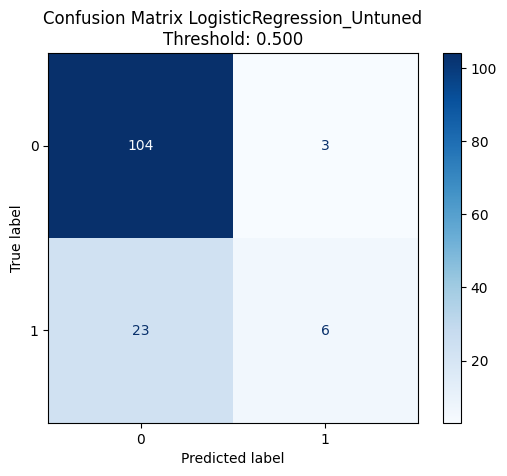

In [ ]:
# Demonstrate WITHOUT tuning
y_pred_no_tune =export_results(best_bench_model, X_test_scaled, y_test,
                          threshold=0.5, suffix=f"{winner_name}_Untuned")

WITH THRESHOLD TUNING (Precision-Recall Optimal)
[with tuned threshold based on PR_Curve (LogisticRegression)] Threshold: 0.374 | AP: 0.359 | F1: 0.383


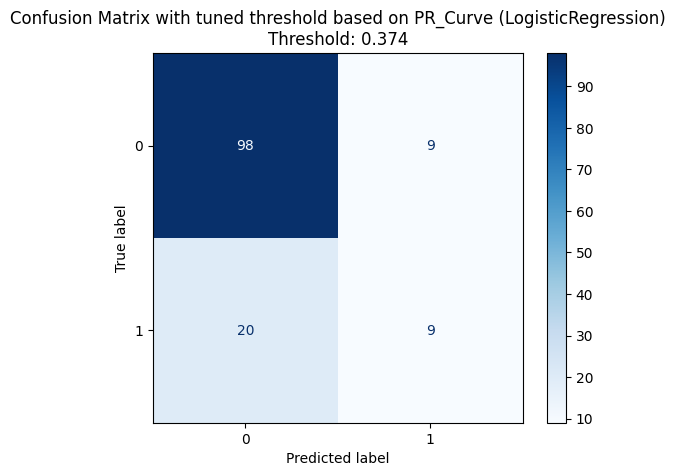

In [ ]:
print("WITH THRESHOLD TUNING (Precision-Recall Optimal)")
# The function automatically calculates the best PR threshold if we don't force one
y_tuned = export_results(
    best_bench_model,
    X_test_scaled,
    y_test,
    suffix=f"with tuned threshold based on PR_Curve ({winner_name})",
    save_file=False
)

In [ ]:
Counter(y_pred_no_tune == y_tuned)

Counter({np.True_: 127, np.False_: 9})